In [1]:
# PHASE 7 — LLMs & IA GÉNÉRATIVE
# On va utiliser l'API Claude d'Anthropic directement

# Installation
import subprocess
subprocess.run(["pip", "install", "anthropic"], capture_output=True)

import anthropic
print(f"Anthropic SDK installé ✅")

# Les LLMs (Large Language Models) sont des modèles entraînés
# sur des milliards de textes pour prédire le prochain token
# 
# Exemples : GPT-4 (OpenAI), Claude (Anthropic), Gemini (Google), LLaMA (Meta)
#
# Architecture de base : Transformer
# - Tokenisation : texte → IDs numériques
# - Embeddings : IDs → vecteurs denses
# - Attention : chaque token "regarde" tous les autres
# - Prédiction : probabilité du prochain token

# Concepts clés
concepts = {
    "Token": "Unité de base du texte (~4 caractères en moyenne)",
    "Context Window": "Nombre max de tokens que le modèle peut traiter à la fois",
    "Temperature": "Contrôle la créativité (0=déterministe, 1=créatif)",
    "Top-p": "Contrôle la diversité des tokens choisis",
    "System Prompt": "Instructions données au modèle avant la conversation",
    "Few-shot": "Donner des exemples dans le prompt",
    "RAG": "Retrieval Augmented Generation - enrichir le modèle avec des données externes"
}

print("=== CONCEPTS CLÉS DES LLMs ===\n")
for concept, definition in concepts.items():
    print(f"• {concept:20s} : {definition}")

Anthropic SDK installé ✅
=== CONCEPTS CLÉS DES LLMs ===

• Token                : Unité de base du texte (~4 caractères en moyenne)
• Context Window       : Nombre max de tokens que le modèle peut traiter à la fois
• Temperature          : Contrôle la créativité (0=déterministe, 1=créatif)
• Top-p                : Contrôle la diversité des tokens choisis
• System Prompt        : Instructions données au modèle avant la conversation
• Few-shot             : Donner des exemples dans le prompt
• RAG                  : Retrieval Augmented Generation - enrichir le modèle avec des données externes


In [2]:
# TOKENISATION — comment le texte devient des nombres
# Les LLMs ne voient pas du texte, ils voient des IDs numériques

import re

# Tokeniseur simple pour comprendre le concept
def tokenize_simple(text):
    # Séparer par mots et ponctuation
    tokens = re.findall(r"\w+|[^\w\s]", text.lower())
    return tokens

texte = "Le Deep Learning révolutionne l'Intelligence Artificielle en 2026!"
tokens = tokenize_simple(texte)
print(f"Texte original : {texte}")
print(f"Tokens : {tokens}")
print(f"Nombre de tokens : {len(tokens)}")

print("\n=== VOCABULAIRE ET IDs ===")
# Créer un vocabulaire simple
vocab = {token: i for i, token in enumerate(sorted(set(tokens)))}
print(f"Vocabulaire : {vocab}")

# Encoder le texte
ids = [vocab[t] for t in tokens if t in vocab]
print(f"\nIDs : {ids}")

print("\n=== TOKENISEUR HUGGING FACE ===")
from transformers import AutoTokenizer

# Tokeniseur de GPT-2
tokenizer = AutoTokenizer.from_pretrained("distilgpt2")

texte_en = "Deep Learning is revolutionizing Artificial Intelligence!"
tokens_hf = tokenizer.encode(texte_en)
print(f"Texte : {texte_en}")
print(f"IDs   : {tokens_hf}")
print(f"Tokens: {tokenizer.convert_ids_to_tokens(tokens_hf)}")
print(f"Nombre de tokens : {len(tokens_hf)}")

# Décoder
decoded = tokenizer.decode(tokens_hf)
print(f"Décodé : {decoded}")

Texte original : Le Deep Learning révolutionne l'Intelligence Artificielle en 2026!
Tokens : ['le', 'deep', 'learning', 'révolutionne', 'l', "'", 'intelligence', 'artificielle', 'en', '2026', '!']
Nombre de tokens : 11

=== VOCABULAIRE ET IDs ===
Vocabulaire : {'!': 0, "'": 1, '2026': 2, 'artificielle': 3, 'deep': 4, 'en': 5, 'intelligence': 6, 'l': 7, 'le': 8, 'learning': 9, 'révolutionne': 10}

IDs : [8, 4, 9, 10, 7, 1, 6, 3, 5, 2, 0]

=== TOKENISEUR HUGGING FACE ===


Texte : Deep Learning is revolutionizing Artificial Intelligence!
IDs   : [29744, 18252, 318, 5854, 2890, 35941, 9345, 0]
Tokens: ['Deep', 'ĠLearning', 'Ġis', 'Ġrevolution', 'izing', 'ĠArtificial', 'ĠIntelligence', '!']
Nombre de tokens : 8
Décodé : Deep Learning is revolutionizing Artificial Intelligence!


In [3]:
# PROMPT ENGINEERING
# L'art de formuler les bonnes instructions pour obtenir les meilleurs résultats

# Différentes techniques de prompting

prompts = {
    "Zero-Shot": """
Classifie ce texte en POSITIF, NÉGATIF ou NEUTRE.
Texte : "Ce produit est correct mais pourrait être amélioré."
Réponse :""",

    "Few-Shot": """
Classifie ces textes en POSITIF, NÉGATIF ou NEUTRE.

Exemples :
Texte : "J'adore ce produit !" → POSITIF
Texte : "Horrible, ne fonctionne pas." → NÉGATIF
Texte : "Le produit est livré." → NEUTRE

Texte : "Ce produit est correct mais pourrait être amélioré."
Réponse :""",

    "Chain-of-Thought": """
Classifie ce texte en POSITIF, NÉGATIF ou NEUTRE.
Pense étape par étape avant de répondre.

Texte : "Ce produit est correct mais pourrait être amélioré."

Raisonnement :
1. Le mot "correct" est neutre/légèrement positif
2. "mais pourrait être amélioré" indique une insatisfaction partielle
3. Le sentiment global est...
Réponse :""",

    "Role Prompting": """
Tu es un expert en analyse de sentiment avec 10 ans d'expérience 
en traitement du langage naturel.

Analyse ce texte et donne une classification précise :
Texte : "Ce produit est correct mais pourrait être amélioré."
Classification :"""
}

print("=== TECHNIQUES DE PROMPT ENGINEERING ===\n")
for technique, prompt in prompts.items():
    print(f"{'='*50}")
    print(f"Technique : {technique}")
    print(f"Prompt :{prompt}")
    print()

print("=== STRUCTURE D'UN BON PROMPT ===")
print("""
1. RÔLE      → "Tu es un expert en..."
2. CONTEXTE  → "Dans le cadre de..."
3. TÂCHE     → "Analyse/Génère/Classe..."
4. FORMAT    → "Réponds en JSON / en 3 points / en moins de 100 mots"
5. EXEMPLES  → "Voici des exemples : ..."
6. CONTRAINTES → "Ne pas inclure... / Toujours..."
""")

=== TECHNIQUES DE PROMPT ENGINEERING ===

Technique : Zero-Shot
Prompt :
Classifie ce texte en POSITIF, NÉGATIF ou NEUTRE.
Texte : "Ce produit est correct mais pourrait être amélioré."
Réponse :

Technique : Few-Shot
Prompt :
Classifie ces textes en POSITIF, NÉGATIF ou NEUTRE.

Exemples :
Texte : "J'adore ce produit !" → POSITIF
Texte : "Horrible, ne fonctionne pas." → NÉGATIF
Texte : "Le produit est livré." → NEUTRE

Texte : "Ce produit est correct mais pourrait être amélioré."
Réponse :

Technique : Chain-of-Thought
Prompt :
Classifie ce texte en POSITIF, NÉGATIF ou NEUTRE.
Pense étape par étape avant de répondre.

Texte : "Ce produit est correct mais pourrait être amélioré."

Raisonnement :
1. Le mot "correct" est neutre/légèrement positif
2. "mais pourrait être amélioré" indique une insatisfaction partielle
3. Le sentiment global est...
Réponse :

Technique : Role Prompting
Prompt :
Tu es un expert en analyse de sentiment avec 10 ans d'expérience 
en traitement du langage naturel.


In [4]:
# LANGCHAIN — framework pour construire des applications avec les LLMs
subprocess.run(["pip", "install", "langchain", "langchain-anthropic"], 
               capture_output=True)

from langchain_anthropic import ChatAnthropic
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

import os

# Pour utiliser Claude, tu as besoin d'une API key Anthropic
# Va sur console.anthropic.com pour créer une clé gratuite
# Puis remplace "ta_cle_ici" par ta vraie clé

API_KEY = "ta_cle_ici"   # ← remplace par ta clé

if API_KEY == "ta_cle_ici":
    print("⚠️  Tu n'as pas encore de clé API Anthropic.")
    print("   Voici comment en obtenir une gratuitement :")
    print("   1. Va sur https://console.anthropic.com")
    print("   2. Crée un compte")
    print("   3. Va dans 'API Keys' → 'Create Key'")
    print("   4. Copie la clé et remplace 'ta_cle_ici' dans ce code")
    print("\n   Une fois la clé obtenue, reviens ici et réexécute cette cellule.")
else:
    os.environ["ANTHROPIC_API_KEY"] = API_KEY
    
    # Créer le modèle
    llm = ChatAnthropic(model="claude-sonnet-4-6")
    
    # Prompt template
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Tu es un expert en {domaine}. Réponds de façon concise."),
        ("human", "{question}")
    ])
    
    # Chain
    chain = prompt | llm | StrOutputParser()
    
    result = chain.invoke({
        "domaine": "Machine Learning",
        "question": "Explique la descente de gradient en 3 phrases simples."
    })
    
    print("=== RÉPONSE DE CLAUDE ===")
    print(result)

⚠️  Tu n'as pas encore de clé API Anthropic.
   Voici comment en obtenir une gratuitement :
   1. Va sur https://console.anthropic.com
   2. Crée un compte
   3. Va dans 'API Keys' → 'Create Key'
   4. Copie la clé et remplace 'ta_cle_ici' dans ce code

   Une fois la clé obtenue, reviens ici et réexécute cette cellule.


=== MÉCANISME D'ATTENTION ===
Q shape : torch.Size([4, 8])
K shape : torch.Size([4, 8])
V shape : torch.Size([4, 8])
Output shape : torch.Size([4, 8])

Matrice d'attention (weights) :
[[0.194 0.41  0.324 0.071]
 [0.041 0.656 0.086 0.217]
 [0.104 0.206 0.182 0.508]
 [0.193 0.18  0.195 0.432]]
→ Chaque ligne = distribution de probabilité sur les tokens
→ weights[i][j] = importance du token j pour le token i


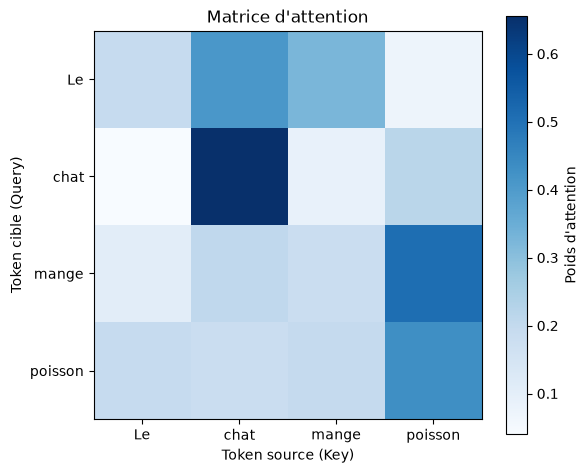

In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# L'ATTENTION — le coeur du Transformer
# Pour chaque token, calculer l'importance des autres tokens

def attention(Q, K, V):
    """
    Q = Query  (ce qu'on cherche)
    K = Key    (ce qu'on offre)
    V = Value  (l'information réelle)
    """
    d_k = Q.shape[-1]
    
    # Score d'attention
    scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(d_k)
    
    # Softmax → distribution de probabilité
    weights = torch.softmax(scores, dim=-1)
    
    # Weighted sum des values
    output = torch.matmul(weights, V)
    
    return output, weights

# Exemple simple : 4 tokens, dimension 8
seq_len = 4
d_model = 8

# Simuler Q, K, V
torch.manual_seed(42)
Q = torch.randn(seq_len, d_model)
K = torch.randn(seq_len, d_model)
V = torch.randn(seq_len, d_model)

output, weights = attention(Q, K, V)

print("=== MÉCANISME D'ATTENTION ===")
print(f"Q shape : {Q.shape}")
print(f"K shape : {K.shape}")
print(f"V shape : {V.shape}")
print(f"Output shape : {output.shape}")

print(f"\nMatrice d'attention (weights) :")
print(weights.detach().numpy().round(3))
print("→ Chaque ligne = distribution de probabilité sur les tokens")
print("→ weights[i][j] = importance du token j pour le token i")

# Visualisation
plt.figure(figsize=(6, 5))
plt.imshow(weights.detach().numpy(), cmap="Blues")
plt.colorbar(label="Poids d'attention")
plt.title("Matrice d'attention")
plt.xlabel("Token source (Key)")
plt.ylabel("Token cible (Query)")
tokens = ["Le", "chat", "mange", "poisson"]
plt.xticks(range(4), tokens)
plt.yticks(range(4), tokens)
plt.tight_layout()
plt.show()